# Naive Bayes (Bayes Ingenuo)

Permite calcular la probabilidad de que un dato pertenezca a una categoría dada con base en sus características. Se le llama "Naive" (ingenuo) porque asume que todas las características son **independientes entre sí**, lo cual no siempre es cierto, pero suele funcionar bien en muchos casos prácticos.

# Teorema de Bayes

El **Teorema de Bayes** nos permite calcular la **probabilidad posterior** de un evento \( C \) dado un conjunto de observaciones \( X \). Se puede expresar como:

$$
P(C|X) = \frac{P(X|C) \cdot P(C)}{P(X)}
$$

## Donde:

- \( P(C|X) \): Probabilidad de que el dato pertenezca a la clase \( C \), dado el conjunto de características \( X \) (probabilidad posterior).
- \( P(X|C) \): Probabilidad de observar las características \( X \) en la clase \( C \) (probabilidad verosimilitud).
- \( P(C) \): Probabilidad previa de la clase \( C \), antes de observar \( X \) (probabilidad a priori).
- \( P(X) \): Probabilidad total de las características \( X \), independientemente de la clase.

---


## Fórmula general de Naive Bayes:

Cuando usamos el **algoritmo Naive Bayes**, asumimos que las características \( X = (x_1, x_2, ... , x_m) \) son **independientes** entre sí, dado que la clase es conocida. Esto simplifica la fórmula a:

$$
P(C|X) = \frac{P(C) \cdot \prod_{i=1}^{m} P(x_i|C)}{P(X)}
$$

En esta fórmula:

- \( P(C) \) es la probabilidad a priori de la clase.
- \( P(x_i|C) \) es la probabilidad de que la característica \( x_i \) ocurra dado que el dato pertenece a la clase \( C \).
- \( P(X) \) es la probabilidad total de las características, que sirve para normalizar las predicciones y asegurarse de que las probabilidades sumen 1.

Dado que \( P(X) \) es constante para todas las clases, se puede omitir durante la predicción, y solo nos enfocamos en maximizar el producto \( P(C) \cdot \prod_{i=1}^{m} P(x_i|C) \) para calcular la clase más probable:

$$
\hat{C} = \arg\max_C \left( P(C) \cdot \prod_{i=1}^{m} P(x_i|C) \right)
$$



### INPUT
- Variables numéricas (gausiano)
- Si tenemos variable cualitativas, debemos usar un OneHotEncodder o similar

### OUTPUT
- Categoría discreta (clasificación)
- Variable numérica continua 

### Para Evaluación del modelo:
- Clasificación:
    - Matriz de confusión, accuracy, precission, recall, f1
- Variable numérica continua:
    - RMSE (más común)

In [14]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import random
import statsmodels.api as sm
import statsmodels.stats.diagnostic as smd
import pandas as pd
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error,r2_score
import seaborn as sns
import statsmodels.api as sm
import scipy.stats as stats
import statsmodels.stats.diagnostic as diag
from sklearn.naive_bayes import GaussianNB
#Metrics
from sklearn.metrics import make_scorer, accuracy_score,precision_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score ,precision_score,recall_score,f1_score

## Cargando y explorando el conjunto de datos

In [15]:
iris = datasets.load_iris()
#Transformando a un dataframe de pandas
datos = pd.DataFrame(data= np.c_[iris['data'], iris['target']],
                     columns= iris['feature_names'] + ['target'])
#Cambiandole los nombres a las columnas
datos.columns=["Sepal.length","Sepal.width","Petal.length","Petal.width","Specie"]
datos

,Sepal.length,Sepal.width,Petal.length,Petal.width,Specie
0,5.1,3.5,1.4,0.2,0.0
1,4.9,3.0,1.4,0.2,0.0
2,4.7,3.2,1.3,0.2,0.0
3,4.6,3.1,1.5,0.2,0.0
4,5.0,3.6,1.4,0.2,0.0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2.0
146,6.3,2.5,5.0,1.9,2.0
147,6.5,3.0,5.2,2.0,2.0
148,6.2,3.4,5.4,2.3,2.0


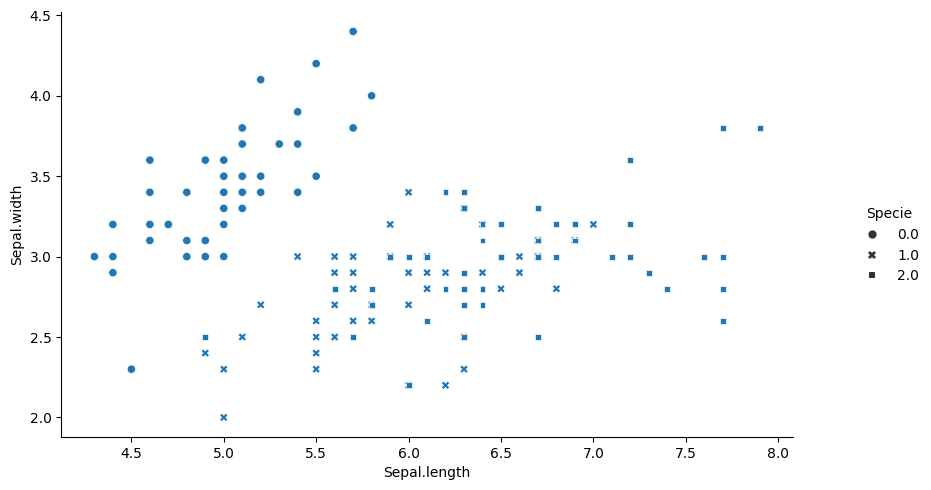

In [16]:
g=sns.relplot(x='Sepal.length',y='Sepal.width',data=datos,style='Specie')
g.fig.set_size_inches(10,5)
plt.show()

Exploremos todo - ¿qué vemos en la diagonal? 

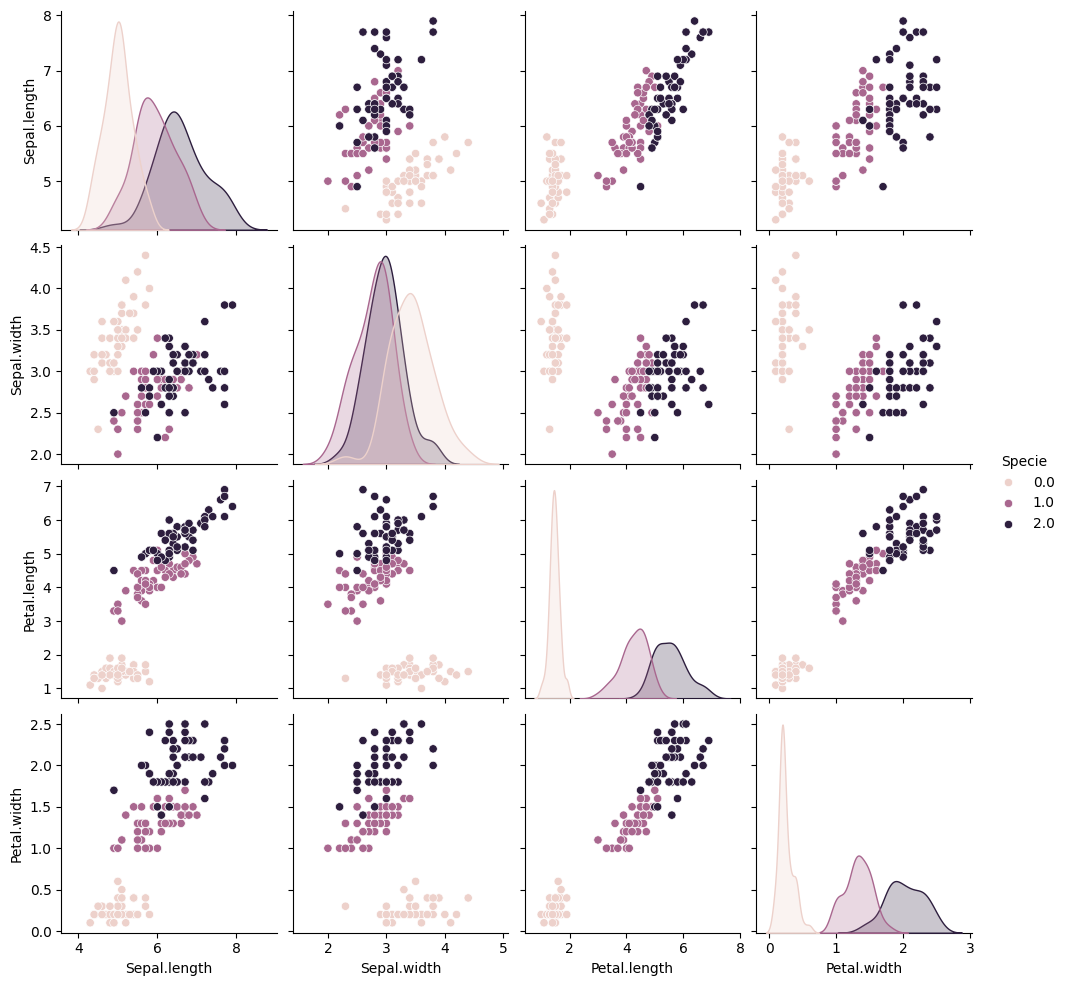

In [17]:
sns.pairplot(datos,hue="Specie")
plt.show()

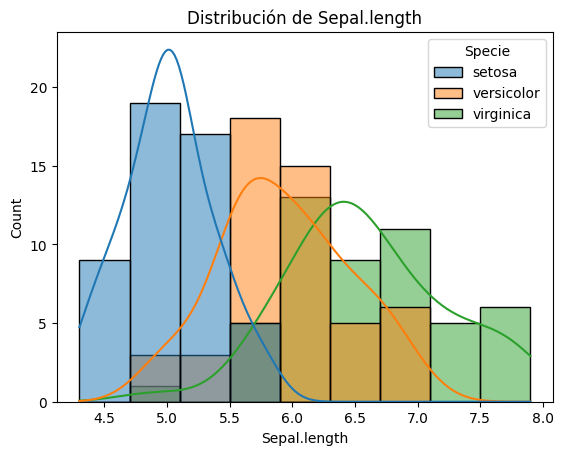

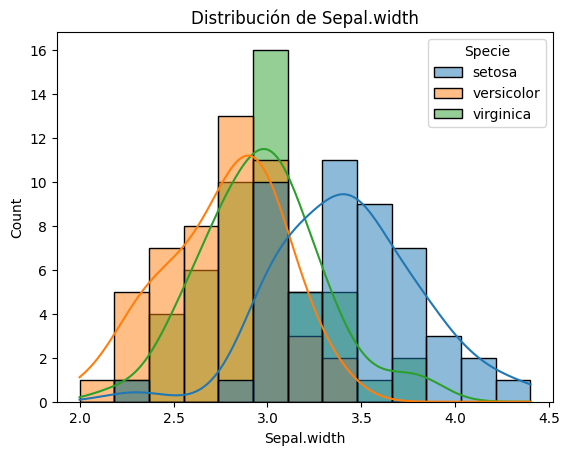

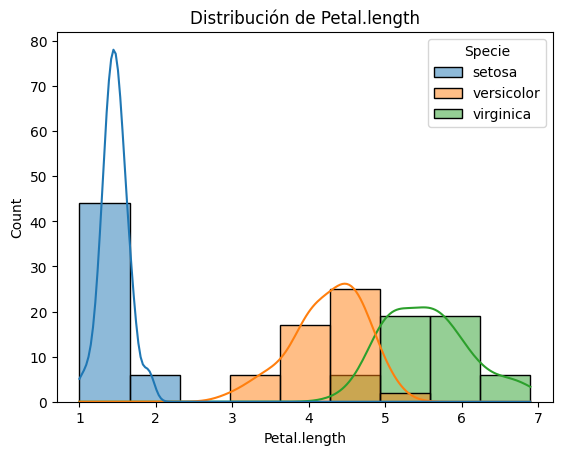

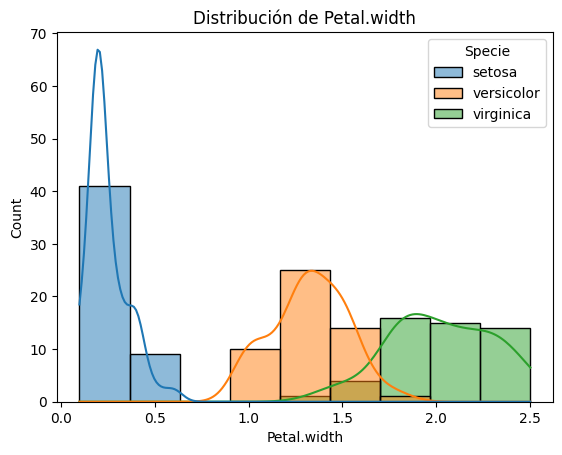

In [18]:
# convertir la variable target a nombres de especie
datos["Specie"] = datos["Specie"].map({
    0: "setosa",
    1: "versicolor",
    2: "virginica"
})

# Lista de variables
variables = ["Sepal.length","Sepal.width","Petal.length","Petal.width"]

# Graficar distribuciones
for col in variables:
    plt.figure()
    sns.histplot(data=datos, x=col, hue="Specie", kde=True)
    plt.title(f"Distribución de {col}")
    plt.show()

In [19]:
Specie = datos.pop("Specie") 
datos.corr()

,Sepal.length,Sepal.width,Petal.length,Petal.width
Sepal.length,1.000000,-0.117570,0.871754,0.817941
Sepal.width,-0.117570,1.000000,-0.428440,-0.366126
Petal.length,0.871754,-0.428440,1.000000,0.962865
Petal.width,0.817941,-0.366126,0.962865,1.000000


- correlación positiva (~1): correlación positiva, si una aumenta, aumenta la otra.
- correlación negativa (~ -1): corr negativa, si una aumenta, disminuye la otra
- correlación 0: No hay relación lineal clara entre las variables

Text(0.5, 1.0, 'Correlación de las variables numéricas de Iris')

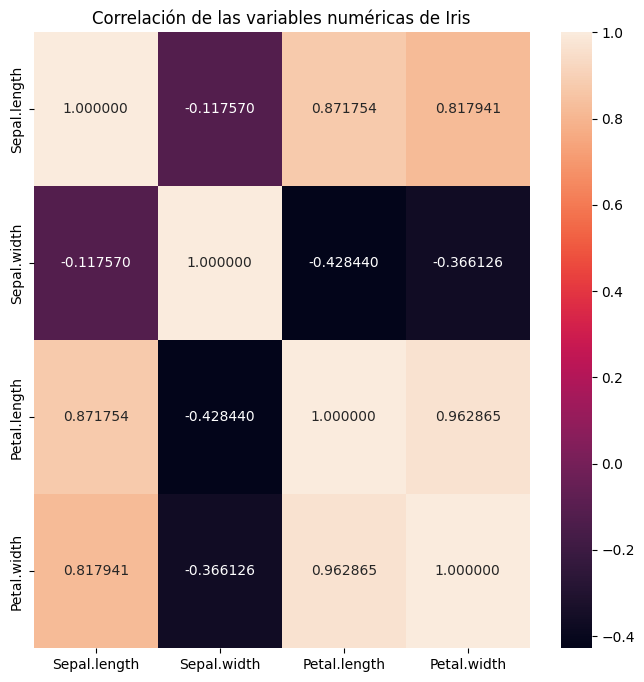

In [20]:
plt.subplots(figsize = (8,8))
sns.heatmap(datos.corr(),annot=True,fmt="f").set_title("Correlación de las variables numéricas de Iris") # ahora como HEATMAP

### Separando en train y test

In [21]:
y = Specie #La variable respuesta
X = datos #El resto de los datos
random.seed(1234)

In [22]:
print(X)

     Sepal.length  Sepal.width  Petal.length  Petal.width
0             5.1          3.5           1.4          0.2
1             4.9          3.0           1.4          0.2
2             4.7          3.2           1.3          0.2
3             4.6          3.1           1.5          0.2
4             5.0          3.6           1.4          0.2
..            ...          ...           ...          ...
145           6.7          3.0           5.2          2.3
146           6.3          2.5           5.0          1.9
147           6.5          3.0           5.2          2.0
148           6.2          3.4           5.4          2.3
149           5.9          3.0           5.1          1.8

[150 rows x 4 columns]


In [23]:
X_train, X_test,y_train, y_test = train_test_split(X, y,test_size=0.3,train_size=0.7)

70% de entrenamiento y 30% prueba

In [24]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 105 entries, 145 to 40
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Sepal.length  105 non-null    float64
 1   Sepal.width   105 non-null    float64
 2   Petal.length  105 non-null    float64
 3   Petal.width   105 non-null    float64
dtypes: float64(4)
memory usage: 4.1 KB


In [25]:
X_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45 entries, 101 to 11
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Sepal.length  45 non-null     float64
 1   Sepal.width   45 non-null     float64
 2   Petal.length  45 non-null     float64
 3   Petal.width   45 non-null     float64
dtypes: float64(4)
memory usage: 1.8 KB


## Creando el modelo

Vamos a crear nuestro primer modelo **NB Gaussiano** (¿por qué?)

In [26]:
gaussian = GaussianNB() # distribución gaussiana. ¿qué significa y qué implica? 

# train
gaussian.fit(X_train,y_train)

# prediction
y_pred = gaussian.predict(X_test)

# eval_model
cm = confusion_matrix(y_test,y_pred)


In [27]:
print('Confusion matrix for Naive Bayes\n',cm)


Confusion matrix for Naive Bayes
 [[16  0  0]
 [ 0 11  1]
 [ 0  2 15]]


##### ¿Cómo lo interpretamos?
- Clase 0 (fila 1): Se predijo correctamente 16 veces y no hubo errores.
- Clase 1 (fila 2): Se predijo correctamente 11 veces, pero 1 vez se confundió con Clase 2.
- Clase 2 (fila 3): Se predijo correctamente 15 veces y hubieron 2 errores.

In [28]:
accuracy=accuracy_score(y_test,y_pred)
precision =precision_score(y_test, y_pred,average='micro')
recall =  recall_score(y_test, y_pred,average='micro')
f1 = f1_score(y_test,y_pred,average='micro')
print('Confusion matrix for Naive Bayes\n',cm)
print('Accuracy: ',accuracy)
print("precision:", precision)
print("recall:", recall)
print("f1: ", f1)

Confusion matrix for Naive Bayes
 [[16  0  0]
 [ 0 11  1]
 [ 0  2 15]]
Accuracy:  0.9333333333333333
precision: 0.9333333333333333
recall: 0.9333333333333333
f1:  0.9333333333333333


### 📊 Métricas de Evaluación de Modelos de Clasificación

#### 🔹 Accuracy (Precisión Global)
La **accuracy** mide la proporción de predicciones correctas sobre el total de muestras:

$$
\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}
$$

---

#### 🔹 Precision (Precisión por Clase)
La precisión mide cuántos de los ejemplos clasificados como positivos eran realmente positivos:

$$
\text{Precision} = \frac{TP}{TP + FP}
$$

---

#### 🔹 Recall (Exhaustividad / Sensibilidad)
El recall mide cuántos de los ejemplos positivos reales fueron correctamente identificados:

$$
\text{Recall} = \frac{TP}{TP + FN}
$$

---

#### 🔹 F1-Score (Promedio Armónico de Precisión y Recall)
El **F1-score** es la media armónica entre la precisión y el recall:

$$
F1 = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}
$$

---

##### 📌 Notación:
- \( TP \) = Verdaderos Positivos (*True Positives*)  
- \( TN \) = Verdaderos Negativos (*True Negatives*)  
- \( FP \) = Falsos Positivos (*False Positives*)  
- \( FN \) = Falsos Negativos (*False Negatives*)  

